In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

2026-02-23 10:30:45.451595: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


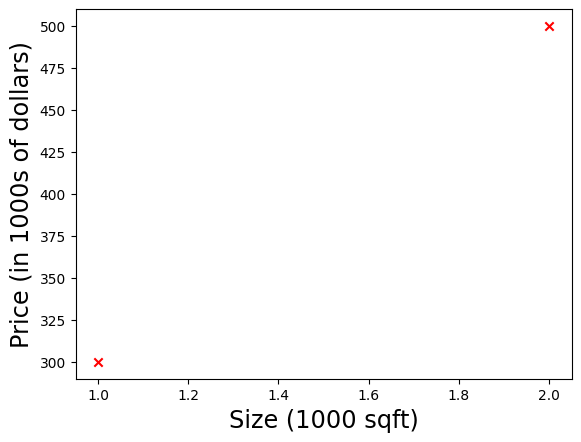

In [20]:
# for simplicity we assume two data points as in house price prediction(size and price)
X_train = np.array([[1.0], [2.0]], dtype=np.float32)           #(size in 1000 square feet)
Y_train = np.array([[300.0], [500.0]], dtype=np.float32)       #(price in 1000s of dollars)

fig, ax = plt.subplots(1,1)
ax.scatter(X_train, Y_train, marker='x', c='r', label="Data Points")
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sqft)', fontsize='xx-large')
plt.show()

In [21]:
linear_layer = tf.keras.layers.Dense(units=1, activation = 'linear', )

#### A linear layer is a layer of neurons which takes in:
- The Input data with the shape (Bacth size , No_of_features)
- The number of neurons is determined by the unit parameter is the case above "1".
- The activation parameter represents the activation function applied to the output of the layer.


In [32]:
a1 = linear_layer(X_train[0].reshape(1,1))

In [33]:
a1

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[-0.6617743]], dtype=float32)>


- a1 above represents the output of the linear transformation for this particular layer.
- we have the result ***-0.661*** which is the linear transformation for the 1 example we passed to the layer of 1 unit 


In [34]:
w,b = linear_layer.get_weights()

In [45]:
w,b

(array([[-0.6617743]], dtype=float32), array([0.], dtype=float32))

- a single example with a single feature will derive a weight of (1,1), a column vector while the bias will be a (1,) a single number. 
    

In [44]:
#### Lets manually set the weight and the bias
set_w = np.array([[45]])
set_b = np.array([5])
linear_layer.set_weights([set_w , set_b])
linear_layer.get_weights()

[array([[45.]], dtype=float32), array([5.], dtype=float32)]

In [73]:
a1 = linear_layer(X_train[0].reshape(1,1))
a2 = np.dot(set_w , X_train[0].reshape(1,1)) + set_b 
a1,a2

(<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[50.]], dtype=float32)>,
 array([[50.]]))

In [82]:
prediction_tf = linear_layer(X_train)
prediction_numpy = np.dot(X_train , set_w) + set_b 


In [86]:
prediction_numpy , prediction_tf

(array([[50.],
        [95.]]),
 <tf.Tensor: shape=(2, 1), dtype=float32, numpy=
 array([[50.],
        [95.]], dtype=float32)>)

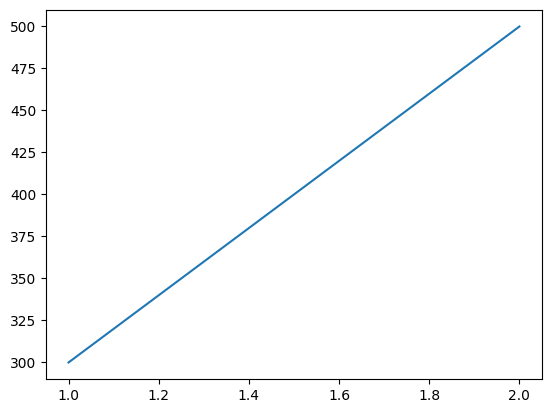

In [90]:
plt.plot(X_train, Y_train)


### Neuron with Sigmoid Activation

The function applied by a neuron (or unit) is the same as logistic regression:

$$
f_{w,b}\left(x^{(i)}\right) = g\left(W x^{(i)} + b\right)
$$

where the activation function is the sigmoid function:

$$
g(z) = \frac{1}{1 + e^{-z}}
$$

In [97]:
X_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1)  # 2-D Matrix
Y_train = np.array([0,  0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1)  # 2-D Matrix


In [99]:
X_train.shape , Y_train.shape

((6, 1), (6, 1))

In [100]:
pos = Y_train == 1
neg = Y_train == 0
X_train[neg]

array([0., 1., 2.], dtype=float32)

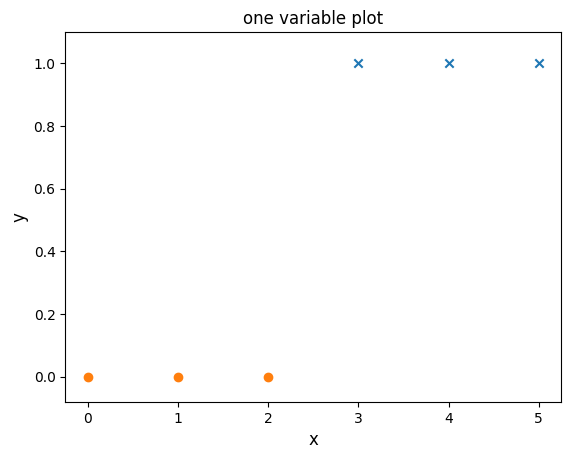

In [103]:

#fig,ax = plt.subplots(1,1,figsize=(4,3))
#ax.scatter(X_train[pos], Y_train[pos], marker='x', s=80, c = 'red', label="y=1")
#ax.scatter(X_train[neg], Y_train[neg], marker='o', s=100, label="y=0", facecolors='none',lw=3)
plt.scatter(X_train[pos], Y_train[pos],marker='x')
plt.scatter(X_train[neg], Y_train[neg],marker='o')
plt.ylim(-0.08,1.1)
plt.ylabel('y', fontsize=12)
plt.xlabel('x', fontsize=12)
plt.title('one variable plot')
plt.show()

#### Logistic Neuron 
We implement the Logisic neuron by adding the sigmoid activation. the function of the neuron is described above.
Now we will create a Tensorflow Model that contains our logistic layer to demonstrate an alternate method of creating models.
Tensorflow is most often used to create multi-layer models. The Sequential model is a convenient means of constructing these models.


In [106]:
model = Sequential( [
                    tf.keras.layers.Dense(units = 1 , input_dim = 1 , activation = "sigmoid" , name = "L1")
                    ] )



In [107]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 L1 (Dense)                  (None, 1)                 2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [112]:
logistic_layer = model.get_layer("L1")
w,b = logistic_layer.get_weights()
print(w,b)
print(w.shape , b.shape)


[[-1.4666383]] [0.]
(1, 1) (1,)


In [126]:
def sigmoid_(z):
    """
    Compute the sigmoid of z.
    
    Parameters:
        z : scalar, list, or numpy array
    
    Returns:
        Sigmoid of z (same shape as input)
    """
    return 1 / (1 + np.exp(-z))

In [127]:
set_w = np.array([2]).reshape(-1,1)
set_b = np.array([-4.5])

logistic_layer.set_weights([set_w,set_b])
log_prediction_tf = model.predict(X_train[0].reshape(1,1))
log_prediction_numpy = sigmoid_(np.dot(X_train[0].reshape(1,1),set_w) + set_b)

print(log_prediction_tf)
print(log_prediction_numpy)

1/1 [==============================] - 0s 43ms/step
[[0.01098694]]
[[0.01098694]]


##### They produce the same values! Now, we can use our logistic layer and NumPy model to make predictions on our training data.

## Congratulations!
You built a very simple neural network and have explored the similarities of a neuron to the linear and logistic regression.